# Adaptive Weight $w$ Analysis

How the learned weight $w$ balances reconstruction vs classification across fractions, modes, and models.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.chdir(os.path.join(os.getcwd(), '..'))

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'font.size': 11,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'axes.grid': False,
    'lines.linewidth': 1.4,
})

In [ ]:
OUTPUTS_DIR = "outputs"
MODEL = "ijepa"          # "mae" or "ijepa"
DATASET = "ucm_mlc"
FRACTIONS = [0.01, 0.05, 0.1, 0.25]

EXP_NAME = f"{MODEL}_{DATASET}"
FRAC_COLORS = plt.cm.viridis(np.linspace(0.2, 0.9, len(FRACTIONS)))
MODE_C = {"semi_supervised": "#2176AE", "supervised": "#E8871E"}

def load_log(exp_name, mode, frac, version=0):
    p = os.path.join(OUTPUTS_DIR, exp_name, mode, f"fl_{frac}",
                     "logs", f"version_{version}", "metrics.csv")
    return pd.read_csv(p) if os.path.exists(p) else None

def get_w_step(df):
    if 'w_step' not in df.columns: return None
    d = df[['step', 'w_step']].dropna()
    return d.rename(columns={'w_step': 'w'}) if not d.empty else None

def get_w_epoch(df):
    for col in ['w_epoch', 'w']:
        if col in df.columns:
            d = df[['epoch', col]].dropna()
            if not d.empty:
                return d.groupby('epoch').mean().reset_index().rename(columns={col: 'w'})
    return None

## $w$ trajectory across fractions

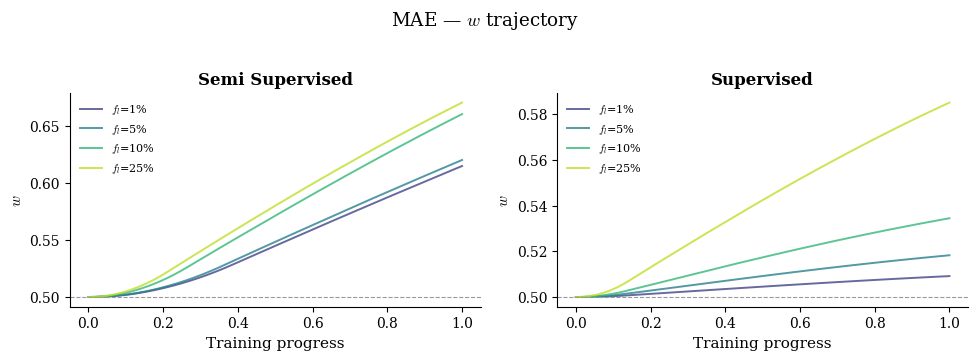

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

for ax, mode in zip(axes, ['semi_supervised', 'supervised']):
    for i, frac in enumerate(FRACTIONS):
        df = load_log(EXP_NAME, mode, frac)
        if df is None: continue
        d = get_w_step(df)
        if d is None: continue
        progress = d['step'] / max(d['step'].max(), 1)
        ax.plot(progress, d['w'], label=f"$f_l$={int(frac*100)}%",
                color=FRAC_COLORS[i], alpha=0.8)
    ax.axhline(0.5, color='#999', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Training progress')
    ax.set_ylabel(r'$w$')
    ax.set_title(mode.replace('_', ' ').title())
    ax.legend(frameon=True, edgecolor='none', facecolor='white', fontsize=8)

fig.suptitle(f'{MODEL.upper()} — $w$ trajectory', y=1.02)
plt.tight_layout()
plt.show()

## Final $w$ vs labeled fraction

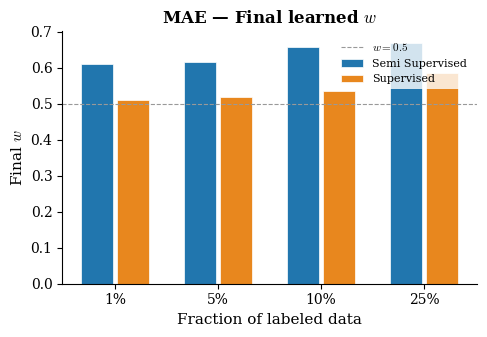

In [4]:
fig, ax = plt.subplots(figsize=(5, 3.5))
bar_width = 0.35
x = np.arange(len(FRACTIONS))

for j, mode in enumerate(['semi_supervised', 'supervised']):
    final_w = []
    for frac in FRACTIONS:
        df = load_log(EXP_NAME, mode, frac)
        if df is None:
            final_w.append(np.nan)
            continue
        d = get_w_epoch(df)
        if d is None: d = get_w_step(df)
        final_w.append(d['w'].iloc[-1] if d is not None else np.nan)

    valid = [not np.isnan(v) for v in final_w]
    offset = (j - 0.5) * bar_width
    ax.bar([x[i] + offset for i in range(len(FRACTIONS)) if valid[i]],
           [final_w[i] for i in range(len(FRACTIONS)) if valid[i]],
           bar_width * 0.9, label=mode.replace('_', ' ').title(),
           color=MODE_C[mode], edgecolor='white', linewidth=0.5)

ax.axhline(0.5, color='#999', linestyle='--', linewidth=0.8, label=r'$w=0.5$')
ax.set_xticks(x)
ax.set_xticklabels([f"{int(f*100)}%" for f in FRACTIONS])
ax.set_xlabel('Fraction of labeled data')
ax.set_ylabel(r'Final $w$')
ax.set_title(f'{MODEL.upper()} — Final learned $w$')
ax.legend(frameon=True, edgecolor='none', facecolor='white', fontsize=8)

plt.tight_layout()
plt.show()

## $w$ vs loss dynamics

How $w$ relates to the reconstruction and classification losses over training.

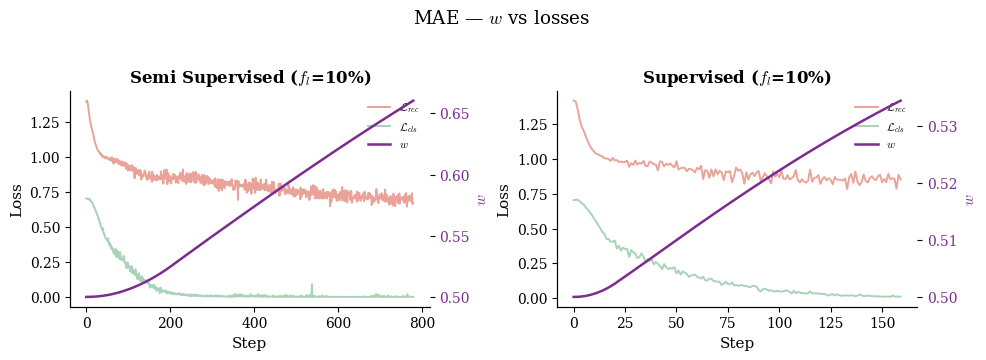

In [5]:
FRAC_DETAIL = 0.1  # fraction to inspect in detail

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

for ax, mode in zip(axes, ['semi_supervised', 'supervised']):
    df = load_log(EXP_NAME, mode, FRAC_DETAIL)
    if df is None:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        continue

    # Get per-step data
    w_data = get_w_step(df)
    r_data = df[['step', 'r_loss_step']].dropna().rename(columns={'r_loss_step': 'r_loss'}) if 'r_loss_step' in df.columns else None
    c_data = df[['step', 'c_loss_step']].dropna().rename(columns={'c_loss_step': 'c_loss'}) if 'c_loss_step' in df.columns else None

    ax2 = ax.twinx()

    if r_data is not None:
        ax.plot(r_data['step'], r_data['r_loss'], color='#D64933', alpha=0.5, label=r'$\mathcal{L}_{rec}$')
    if c_data is not None:
        ax.plot(c_data['step'], c_data['c_loss'], color='#57A773', alpha=0.5, label=r'$\mathcal{L}_{cls}$')
    if w_data is not None:
        ax2.plot(w_data['step'], w_data['w'], color='#7B2D8E', linewidth=1.8, label=r'$w$')

    ax.set_xlabel('Step')
    ax.set_ylabel('Loss')
    ax2.set_ylabel(r'$w$', color='#7B2D8E')
    ax2.tick_params(axis='y', labelcolor='#7B2D8E')

    # Combined legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2,
              frameon=True, edgecolor='none', facecolor='white', fontsize=8)

    ax.set_title(f"{mode.replace('_', ' ').title()} ($f_l$={int(FRAC_DETAIL*100)}%)")

fig.suptitle(f'{MODEL.upper()} — $w$ vs losses', y=1.02)
plt.tight_layout()
plt.show()

## $w$ distribution (histogram)

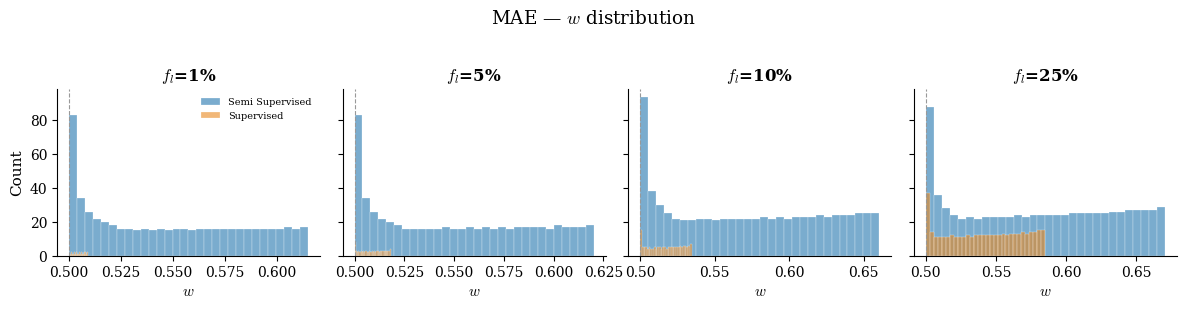

In [6]:
fig, axes = plt.subplots(1, len(FRACTIONS), figsize=(3 * len(FRACTIONS), 3), sharey=True)
if len(FRACTIONS) == 1: axes = [axes]

for i, frac in enumerate(FRACTIONS):
    ax = axes[i]
    for mode, color in MODE_C.items():
        df = load_log(EXP_NAME, mode, frac)
        if df is None: continue
        d = get_w_step(df)
        if d is None: continue
        ax.hist(d['w'].values, bins=30, alpha=0.6, color=color,
                label=mode.replace('_', ' ').title(), edgecolor='white', linewidth=0.3)
    ax.axvline(0.5, color='#999', linestyle='--', linewidth=0.8)
    ax.set_xlabel(r'$w$')
    ax.set_title(f"$f_l$={int(frac*100)}%")
    if i == 0:
        ax.set_ylabel('Count')
        ax.legend(frameon=True, edgecolor='none', facecolor='white', fontsize=7)

fig.suptitle(f'{MODEL.upper()} — $w$ distribution', y=1.02)
plt.tight_layout()
plt.show()

## Effective loss contribution

$(1-w) \cdot \mathcal{L}_{rec}$ vs $w \cdot \mathcal{L}_{cls}$ — the actual weighted contributions.

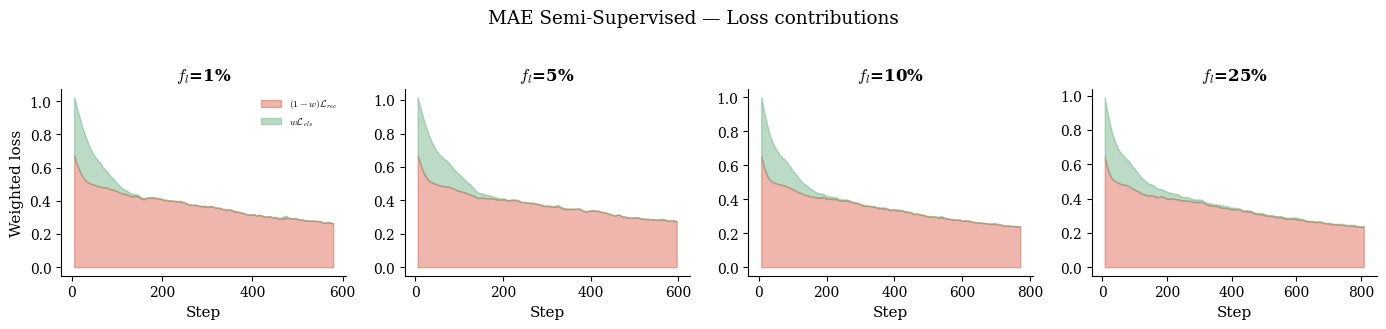

In [7]:
fig, axes = plt.subplots(1, len(FRACTIONS), figsize=(3.5 * len(FRACTIONS), 3.2),
                          sharey=False, squeeze=False)

for i, frac in enumerate(FRACTIONS):
    ax = axes[0, i]
    df = load_log(EXP_NAME, 'semi_supervised', frac)
    if df is None:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        continue

    # Merge step-level data
    merged = df[['step']].copy()
    for col in ['w_step', 'r_loss_step', 'c_loss_step']:
        if col in df.columns:
            merged[col] = df[col]
    merged = merged.dropna(subset=['w_step', 'r_loss_step'])

    if len(merged) == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        continue

    w = merged['w_step'].values
    r = merged['r_loss_step'].values
    c = merged['c_loss_step'].values if 'c_loss_step' in merged.columns else np.zeros_like(r)

    weighted_r = (1 - w) * r
    weighted_c = w * c

    # Smooth with rolling mean
    window = max(len(weighted_r) // 50, 3)
    wr_smooth = pd.Series(weighted_r).rolling(window, center=True).mean()
    wc_smooth = pd.Series(weighted_c).rolling(window, center=True).mean()

    ax.fill_between(range(len(wr_smooth)), 0, wr_smooth, alpha=0.4, color='#D64933',
                    label=r'$(1-w)\mathcal{L}_{rec}$')
    ax.fill_between(range(len(wc_smooth)), wr_smooth, wr_smooth + wc_smooth,
                    alpha=0.4, color='#57A773', label=r'$w\mathcal{L}_{cls}$')

    ax.set_xlabel('Step')
    ax.set_title(f"$f_l$={int(frac*100)}%")
    if i == 0:
        ax.set_ylabel('Weighted loss')
        ax.legend(frameon=True, edgecolor='none', facecolor='white', fontsize=7)

fig.suptitle(f'{MODEL.upper()} Semi-Supervised — Loss contributions', y=1.02)
plt.tight_layout()
plt.show()